In [1]:
# Imports and configuration
import hashlib
import io
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageFile
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models, transforms

ImageFile.LOAD_TRUNCATED_IMAGES = True
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Robust device assignment with fallback
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    try:
        probe = nn.Conv2d(1, 2, 3, padding=1).to(device)
        sample = torch.randn(2, 1, 16, 16, device=device, requires_grad=True)
        probe(sample).mean().backward()
        torch.cuda.synchronize()
        del probe, sample
    except Exception as e:
        print(
            f"CUDA check failed ({e}). Falling back to CPU for execution."
        )
        device = torch.device("cpu")

num_workers = min(4, os.cpu_count() or 2)
pin_memory = device.type == "cuda"
sns.set_theme(style="whitegrid")
print("Device in use:", device)

Device in use: cuda


In [2]:
# Dataset path and settings
DATA_DIR = Path("/kaggle/input/datasets/tashiee/malebin-malware-binary-greyscale-images")
if not DATA_DIR.exists():
    DATA_DIR = Path("/kaggle/input/malebin-malware-binary-greyscale-images")
OUTPUT_DIR = Path("/kaggle/working/task2_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}
CNN_SIZE, GCN_SIZE, PATCH_GRID = 224, 128, 8
BATCH_SIZE = 64
EPOCHS = 8
LR, PATIENCE = 1e-3, 3
assert DATA_DIR.exists(), f"Dataset folder was not found: {DATA_DIR}"
print("Dataset:", DATA_DIR)

Dataset: /kaggle/input/datasets/tashiee/malebin-malware-binary-greyscale-images


In [3]:
# Build the manifest and remove exact duplicates before splitting
import os
import hashlib
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm

DATA_DIR = Path("/kaggle/input/datasets/tashiee/malebin-malware-binary-greyscale-images")
if not DATA_DIR.exists():
    DATA_DIR = Path("/kaggle/input/malebin-malware-binary-greyscale-images")

EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

def sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

assert DATA_DIR.exists(), f"Dataset folder was not found: {DATA_DIR}"

records = []
for folder, _, files in os.walk(DATA_DIR):
    image_names = [
        name for name in files
        if Path(name).suffix.lower() in EXTENSIONS
    ]

    if image_names:
        label = Path(folder).relative_to(DATA_DIR).as_posix()

        for name in image_names:
            records.append(
                {
                    "path": str(Path(folder) / name),
                    "filename": name,
                    "label": label,
                }
            )

manifest = (
    pd.DataFrame(records)
    .sort_values(["label", "filename"])
    .reset_index(drop=True)
)

assert not manifest.empty, "No images were found."

manifest["sha256"] = [
    sha256(path)
    for path in tqdm(manifest["path"], desc="Hashing images")
]

labels_per_hash = manifest.groupby("sha256")["label"].nunique()
cross_class_hashes = set(labels_per_hash[labels_per_hash > 1].index)

clean = manifest.loc[
    ~manifest["sha256"].isin(cross_class_hashes)
    & ~manifest.duplicated("sha256", keep="first")
].copy()

print(f"Original images: {len(manifest):,}")
print(f"Cross-class duplicate groups removed: {len(cross_class_hashes):,}")
print(f"Usable images: {len(clean):,}")

Hashing images:   0%|          | 0/12464 [00:00<?, ?it/s]

Original images: 12,464
Cross-class duplicate groups removed: 499
Usable images: 9,232


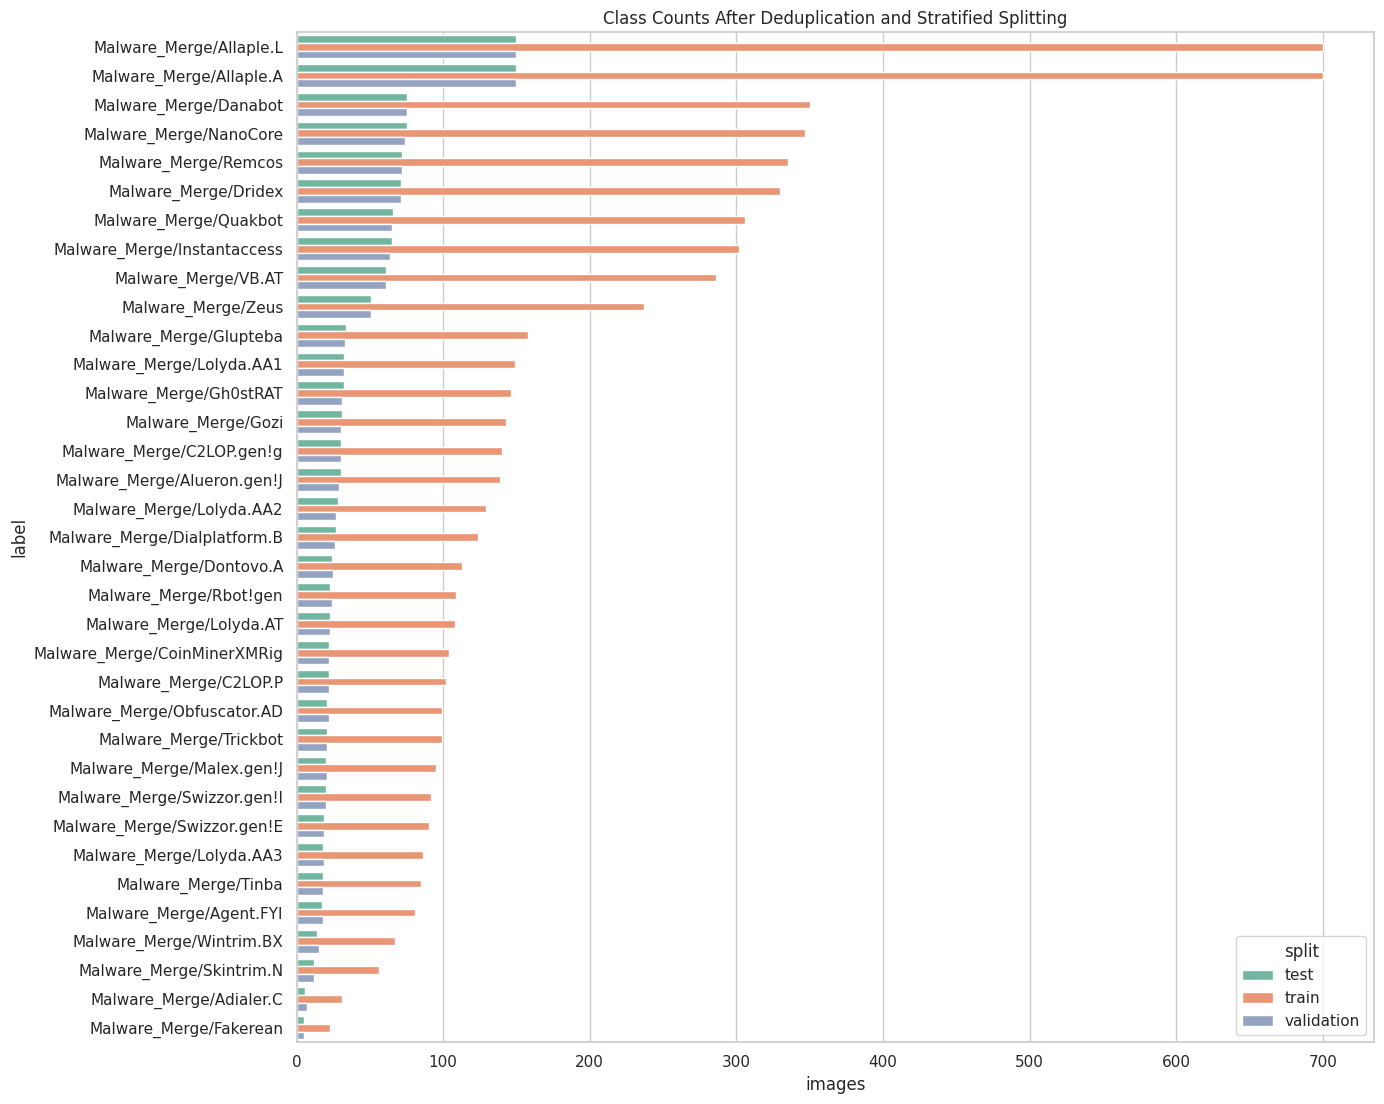

split
train         6461
test          1385
validation    1384
Name: count, dtype: int64


In [4]:
# Checking Class Balancing And Data Leaskage Pipeline
clean = clean[clean.label.isin(clean.label.value_counts().loc[lambda x: x >= 10].index)].copy()
train_df, heldout_df = train_test_split(clean, test_size=.30, stratify=clean.label, random_state=SEED)
validation_df, test_df = train_test_split(heldout_df, test_size=.50, stratify=heldout_df.label, random_state=SEED)
encoder = LabelEncoder().fit(clean.label)
for frame, split in [(train_df, "train"), (validation_df, "validation"), (test_df, "test")]:
    frame["split"] = split
    frame["label_id"] = encoder.transform(frame.label)
split_manifest = pd.concat([train_df, validation_df, test_df], ignore_index=True)
split_manifest.to_csv(OUTPUT_DIR / "split_manifest_deduplicated.csv", index=False)
pd.DataFrame({"label": encoder.classes_, "label_id": range(len(encoder.classes_))}).to_csv(OUTPUT_DIR / "label_map.csv", index=False)
counts = split_manifest.groupby(["label", "split"]).size().reset_index(name="images")
plt.figure(figsize=(14, max(8, len(encoder.classes_) * .32)))
sns.barplot(data=counts, y="label", x="images", hue="split", order=split_manifest.label.value_counts().index, palette="Set2")
plt.title("Class Counts After Deduplication and Stratified Splitting")
plt.tight_layout()
plt.show()
print(split_manifest.split.value_counts())

In [5]:
# Transformations, patch statistics, datasets, and loaders
cnn_train_tf = transforms.Compose([transforms.Resize((CNN_SIZE, CNN_SIZE)), transforms.RandomAffine(0, translate=(.02, .02)), transforms.ToTensor(), transforms.Normalize([.5], [.5])])
cnn_eval_tf = transforms.Compose([transforms.Resize((CNN_SIZE, CNN_SIZE)), transforms.ToTensor(), transforms.Normalize([.5], [.5])])
gcn_tf = transforms.Compose([transforms.Resize((GCN_SIZE, GCN_SIZE)), transforms.ToTensor()])
patch = GCN_SIZE // PATCH_GRID
nodes = PATCH_GRID * PATCH_GRID

def patch_features(image):
    blocks = image.unfold(1, patch, patch).unfold(2, patch, patch).contiguous().view(1, PATCH_GRID, PATCH_GRID, -1).squeeze(0)
    values = [blocks.mean(-1), blocks.std(-1, unbiased=False), blocks.min(-1).values, blocks.max(-1).values, (blocks < 50 / 255).float().mean(-1), (blocks > 205 / 255).float().mean(-1)]
    return torch.stack(values, -1).view(nodes, 6)

class MalwareDataset(Dataset):
    def __init__(self, frame, transform, graph=False):
        self.frame, self.transform, self.graph = frame.reset_index(drop=True), transform, graph
    def __len__(self):
        return len(self.frame)
    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row.path) as image:
            x = self.transform(image.convert("L"))
        return (patch_features(x) if self.graph else x), int(row.label_id)

weights = train_df.label_id.map(1 / train_df.label_id.value_counts()).to_numpy()
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)
def loaders(graph=False):
    train_tf = gcn_tf if graph else cnn_train_tf
    eval_tf = gcn_tf if graph else cnn_eval_tf
    datasets = [MalwareDataset(train_df, train_tf, graph), MalwareDataset(validation_df, eval_tf, graph), MalwareDataset(test_df, eval_tf, graph)]
    return (DataLoader(datasets[0], BATCH_SIZE, sampler=sampler, num_workers=num_workers, pin_memory=pin_memory), DataLoader(datasets[1], BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=pin_memory), DataLoader(datasets[2], BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=pin_memory))
cnn_loaders, gcn_loaders = loaders(), loaders(True)

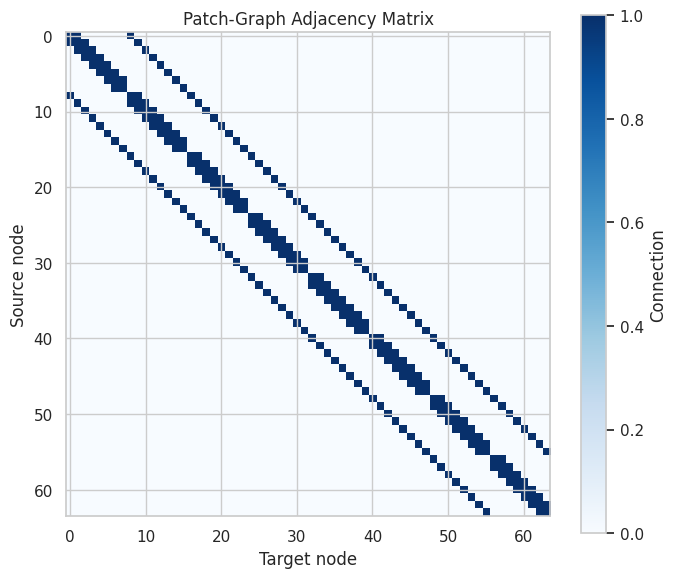

Nodes per image: 64; features per node: 6; patch size: 16×16


In [6]:
# Construction and visualization the fixed patch graph
adjacency = torch.eye(nodes)
for r in range(PATCH_GRID):
    for c in range(PATCH_GRID):
        i = r * PATCH_GRID + c
        for dr, dc in [(0, 1), (1, 0)]:
            nr, nc = r + dr, c + dc
            if nr < PATCH_GRID and nc < PATCH_GRID:
                j = nr * PATCH_GRID + nc
                adjacency[i, j] = adjacency[j, i] = 1
degree = adjacency.sum(1)
graph = torch.diag(degree.pow(-.5)) @ adjacency @ torch.diag(degree.pow(-.5))
plt.figure(figsize=(7, 6))
plt.imshow(adjacency, cmap="Blues")
plt.colorbar(label="Connection")
plt.title("Patch-Graph Adjacency Matrix")
plt.xlabel("Target node"); plt.ylabel("Source node")
plt.tight_layout()
plt.show()
print(f"Nodes per image: {nodes}; features per node: 6; patch size: {patch}×{patch}")

In [7]:
# Define the CNN baselines and custom Patch GCN
classes = len(encoder.classes_)
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2), nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2), nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d(1))
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(.35), nn.Linear(128, classes))
    def forward(self, x):
        return self.head(self.features(x))
class GraphLayer(nn.Module):
    def __init__(self, inputs, outputs):
        super().__init__(); self.linear = nn.Linear(inputs, outputs)
    def forward(self, x, a):
        return torch.bmm(a.expand(x.size(0), -1, -1), self.linear(x))
class PatchGCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer("a", graph)
        self.g1, self.g2, self.g3 = GraphLayer(6, 64), GraphLayer(64, 128), GraphLayer(128, 128)
        self.head = nn.Sequential(nn.Dropout(.35), nn.Linear(128, classes))
    def forward(self, x):
        x = F.relu(self.g1(x, self.a))
        x = F.dropout(x, .20, self.training)
        x = F.relu(self.g2(x, self.a))
        return self.head(F.relu(self.g3(x, self.a)).mean(1))
def resnet18():
    m = models.resnet18(weights=None)
    m.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
    m.fc = nn.Linear(m.fc.in_features, classes)
    return m
def mobilenet():
    m = models.mobilenet_v3_small(weights=None)
    first = m.features[0][0]
    m.features[0][0] = nn.Conv2d(1, first.out_channels, first.kernel_size, first.stride, first.padding, bias=False)
    m.classifier[3] = nn.Linear(m.classifier[3].in_features, classes)
    return m
builders = {"SimpleCNN": SimpleCNN, "ResNet18": resnet18, "MobileNetV3Small": mobilenet, "PatchGCN": PatchGCN}

In [8]:
# Define training, metrics, model size, and inference timing
def evaluate(model, loader, criterion):
    model.eval(); losses, truth, pred = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            losses.append(criterion(logits, y).item() * len(y))
            truth.extend(y.cpu().numpy()); pred.extend(logits.argmax(1).cpu().numpy())
    truth, pred = np.array(truth), np.array(pred)
    macro = precision_recall_fscore_support(truth, pred, average="macro", zero_division=0)
    weighted = precision_recall_fscore_support(truth, pred, average="weighted", zero_division=0)
    return {"loss": sum(losses) / len(truth), "accuracy": accuracy_score(truth, pred), "balanced_accuracy": balanced_accuracy_score(truth, pred), "precision_macro": macro[0], "recall_macro": macro[1], "f1_macro": macro[2], "precision_weighted": weighted[0], "recall_weighted": weighted[1], "f1_weighted": weighted[2], "actual": truth, "predicted": pred}

def fit(name, model, ls):
    train_loader, validation_loader, test_loader = ls
    model = model.to(device); criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=.5, patience=1)
    best, best_score, patience, history = None, -1, PATIENCE, []
    for epoch in range(1, EPOCHS + 1):
        model.train(); total_loss = total = 0
        for x, y in tqdm(train_loader, desc=f"{name} {epoch}/{EPOCHS}", leave=False):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x), y); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * len(y); total += len(y)
        v = evaluate(model, validation_loader, criterion); scheduler.step(v["f1_macro"])
        history.append({"model": name, "epoch": epoch, "train_loss": total_loss / total, "validation_accuracy": v["accuracy"], "validation_f1_macro": v["f1_macro"]})
        print(f"{name} | epoch {epoch} | validation accuracy {v['accuracy']:.4f} | macro F1 {v['f1_macro']:.4f}")
        if v["f1_macro"] > best_score:
            best_score, patience = v["f1_macro"], PATIENCE
            best = {k: q.detach().cpu().clone() for k, q in model.state_dict().items()}
        else:
            patience -= 1
            if patience == 0: break
    model.load_state_dict(best)
    result = evaluate(model, test_loader, criterion)
    if device.type == "cuda": torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        for x, _ in test_loader: model(x.to(device))
    if device.type == "cuda": torch.cuda.synchronize()
    result["inference_ms_per_image"] = (time.perf_counter() - start) * 1000 / len(test_loader.dataset)
    buffer = io.BytesIO(); torch.save(model.state_dict(), buffer)
    result["model_size_mb"] = buffer.getbuffer().nbytes / 1024**2
    torch.save(model.state_dict(), OUTPUT_DIR / f"{name.lower()}_best.pt")
    return model, pd.DataFrame(history), result

In [9]:
# Train the three CNN baselines and the Patch GCN
trained, histories, results = {}, [], {}
for name, builder in builders.items():
    trained[name], history, results[name] = fit(name, builder(), gcn_loaders if name == "PatchGCN" else cnn_loaders)
    histories.append(history)
history = pd.concat(histories, ignore_index=True)
history.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
comparison = pd.DataFrame({name: {k: v for k, v in r.items() if isinstance(v, (int, float, np.floating))} for name, r in results.items()}).T.reset_index(names="model").sort_values("f1_macro", ascending=False)
comparison.to_csv(OUTPUT_DIR / "test_model_comparison.csv", index=False)
display(comparison.round(4))

SimpleCNN 1/8:   0%|          | 0/101 [00:00<?, ?it/s]

SimpleCNN | epoch 1 | validation accuracy 0.5383 | macro F1 0.4031


SimpleCNN 2/8:   0%|          | 0/101 [00:00<?, ?it/s]

SimpleCNN | epoch 2 | validation accuracy 0.6105 | macro F1 0.5041


SimpleCNN 3/8:   0%|          | 0/101 [00:00<?, ?it/s]

...

PatchGCN 7/8:   0%|          | 0/101 [00:00<?, ?it/s]

PatchGCN | epoch 7 | validation accuracy 0.5434 | macro F1 0.3970


PatchGCN 8/8:   0%|          | 0/101 [00:00<?, ?it/s]

PatchGCN | epoch 8 | validation accuracy 0.4610 | macro F1 0.4017


,model,loss,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,inference_ms_per_image,model_size_mb
1,ResNet18,0.4554,0.8664,0.8811,0.8576,0.8811,0.8615,0.8754,0.8664,0.8648,1.8352,42.7546
2,MobileNetV3Small,1.2835,0.6469,0.6856,0.6894,0.6856,0.6500,0.7435,0.6469,0.6591,1.4972,6.0531
0,SimpleCNN,1.2381,0.6852,0.6757,0.6735,0.6757,0.6475,0.7043,0.6852,0.6661,1.4415,0.3814
3,PatchGCN,2.0885,0.4433,0.5080,0.3864,0.5080,0.3771,0.4476,0.4433,0.3887,1.7656,0.1326


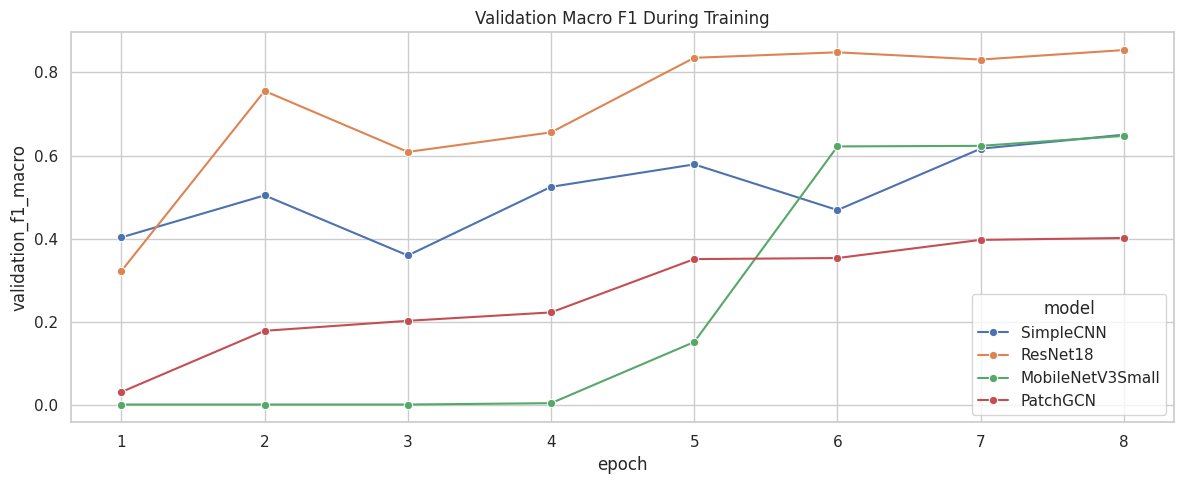

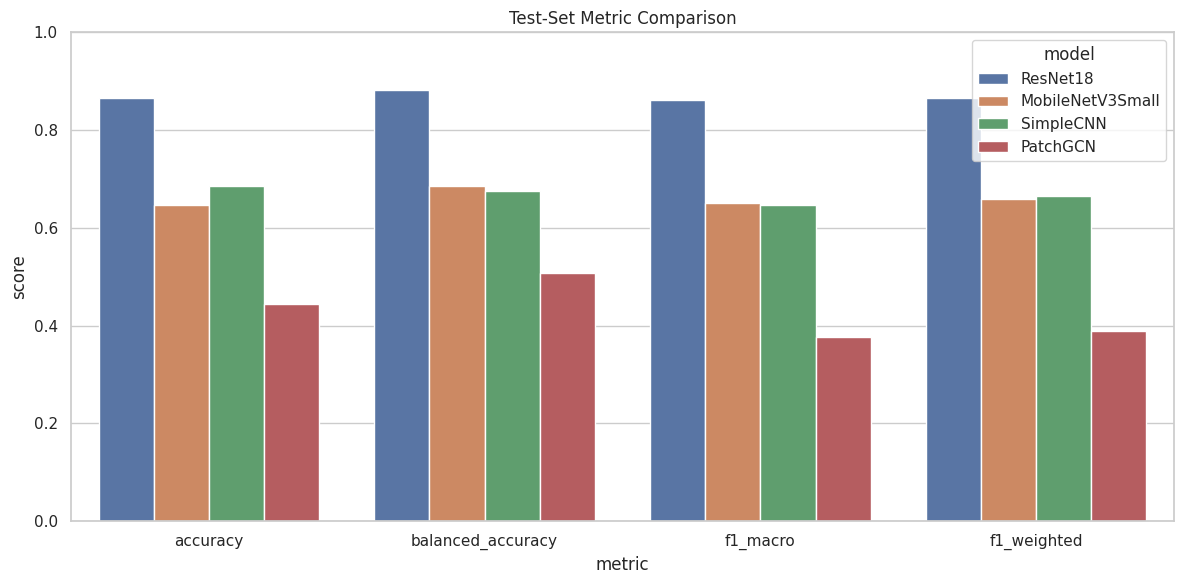

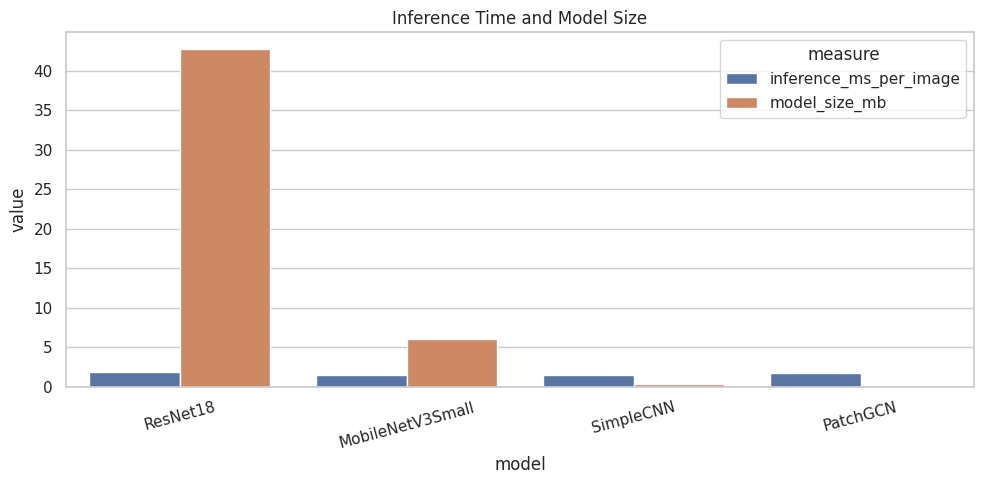

In [10]:
# Visualize the learning curves and the baseline comparison
plt.figure(figsize=(12, 5))
sns.lineplot(data=history, x="epoch", y="validation_f1_macro", hue="model", marker="o")
plt.title("Validation Macro F1 During Training")
plt.tight_layout()
plt.show()
plot_data = comparison.melt(id_vars="model", value_vars=["accuracy", "balanced_accuracy", "f1_macro", "f1_weighted"], var_name="metric", value_name="score")
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_data, x="metric", y="score", hue="model")
plt.ylim(0, 1); plt.title("Test-Set Metric Comparison")
plt.tight_layout()
plt.show()
resources = comparison.melt(id_vars="model", value_vars=["inference_ms_per_image", "model_size_mb"], var_name="measure", value_name="value")
plt.figure(figsize=(10, 5))
sns.barplot(data=resources, x="model", y="value", hue="measure")
plt.title("Inference Time and Model Size"); plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


SimpleCNN classification report


,precision,recall,f1-score,support
Malware_Merge/Adialer.C,0.545,1.000,0.706,6.000
Malware_Merge/Agent.FYI,1.000,1.000,1.000,17.000
Malware_Merge/Allaple.A,0.668,0.980,0.795,150.000
Malware_Merge/Allaple.L,1.000,1.000,1.000,150.000
Malware_Merge/Alueron.gen!J,0.806,0.967,0.879,30.000
Malware_Merge/C2LOP.P,0.778,0.318,0.452,22.000
Malware_Merge/C2LOP.gen!g,0.962,0.833,0.893,30.000
Malware_Merge/CoinMinerXMRig,0.070,0.182,0.101,22.000
Malware_Merge/Danabot,0.714,0.133,0.225,75.000
Malware_Merge/Dialplatform.B,1.000,1.000,1.000,27.000


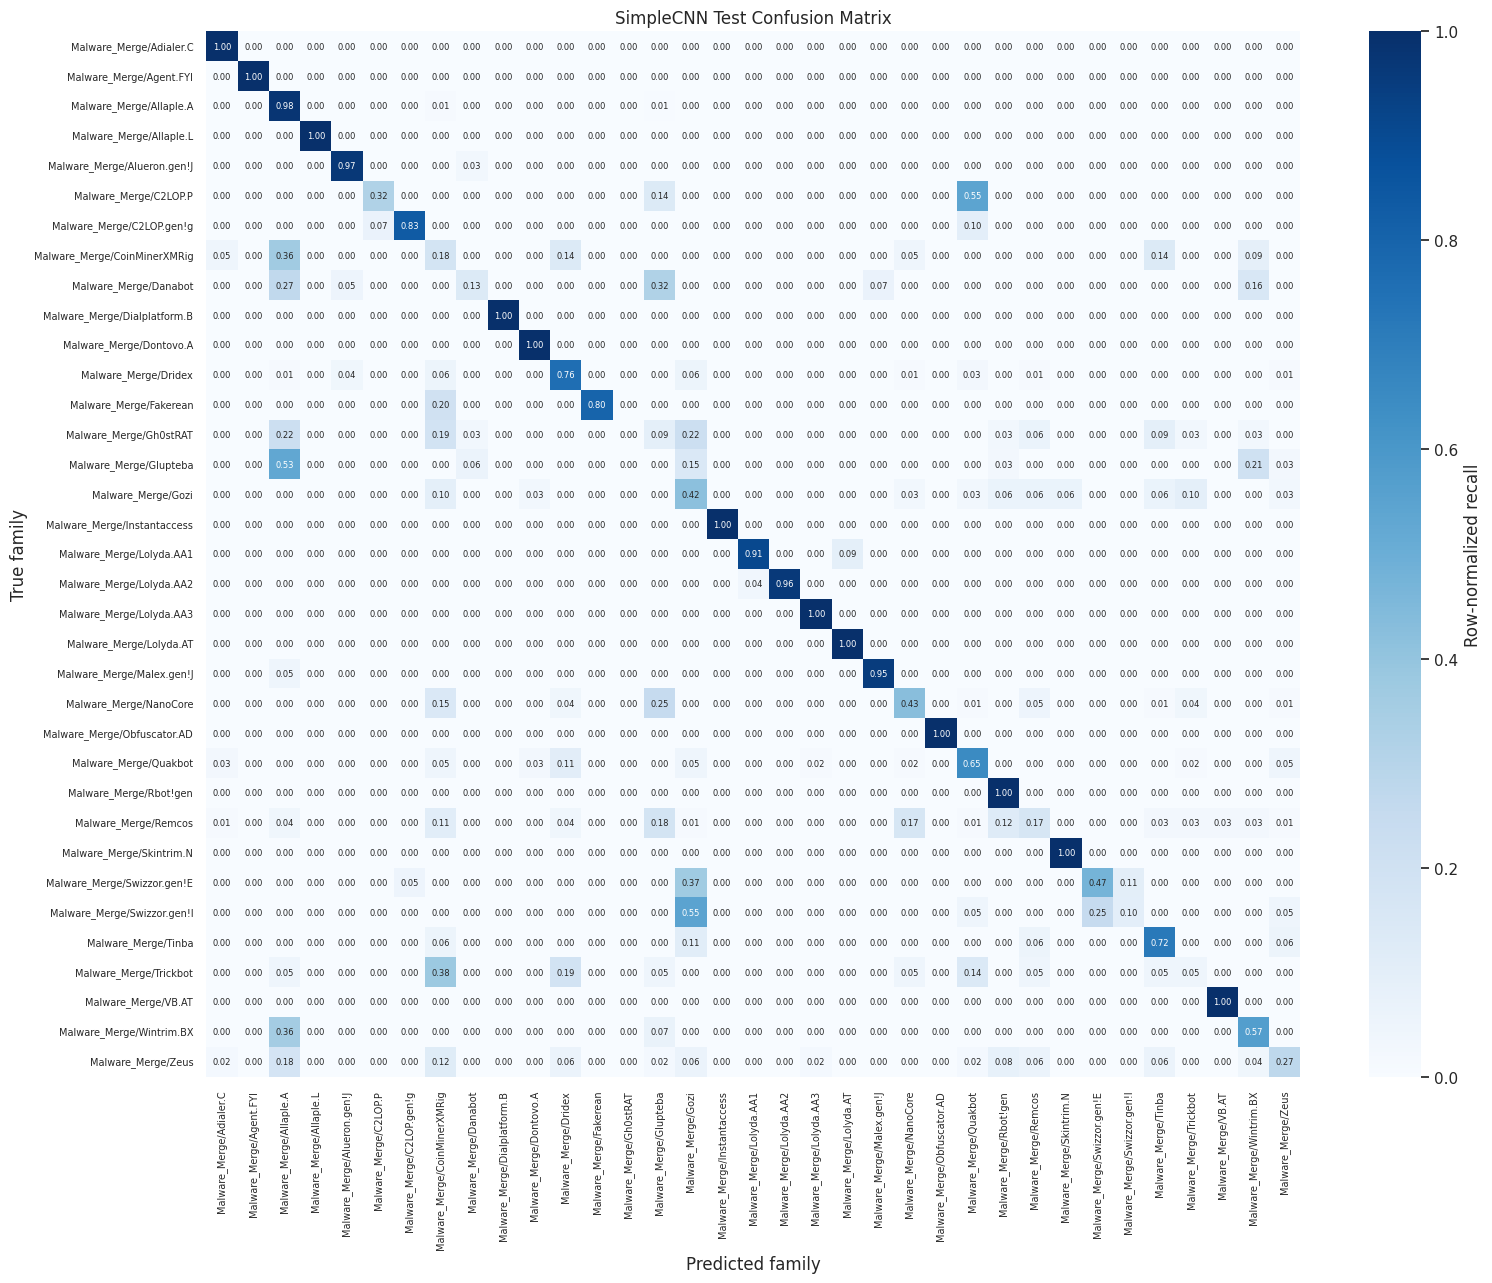


ResNet18 classification report


,precision,recall,f1-score,support
Malware_Merge/Adialer.C,1.000,1.000,1.000,6.000
Malware_Merge/Agent.FYI,1.000,1.000,1.000,17.000
Malware_Merge/Allaple.A,0.993,0.993,0.993,150.000
Malware_Merge/Allaple.L,1.000,1.000,1.000,150.000
Malware_Merge/Alueron.gen!J,0.909,1.000,0.952,30.000
Malware_Merge/C2LOP.P,0.815,1.000,0.898,22.000
Malware_Merge/C2LOP.gen!g,0.931,0.900,0.915,30.000
Malware_Merge/CoinMinerXMRig,0.333,0.591,0.426,22.000
Malware_Merge/Danabot,0.945,0.693,0.800,75.000
Malware_Merge/Dialplatform.B,1.000,1.000,1.000,27.000


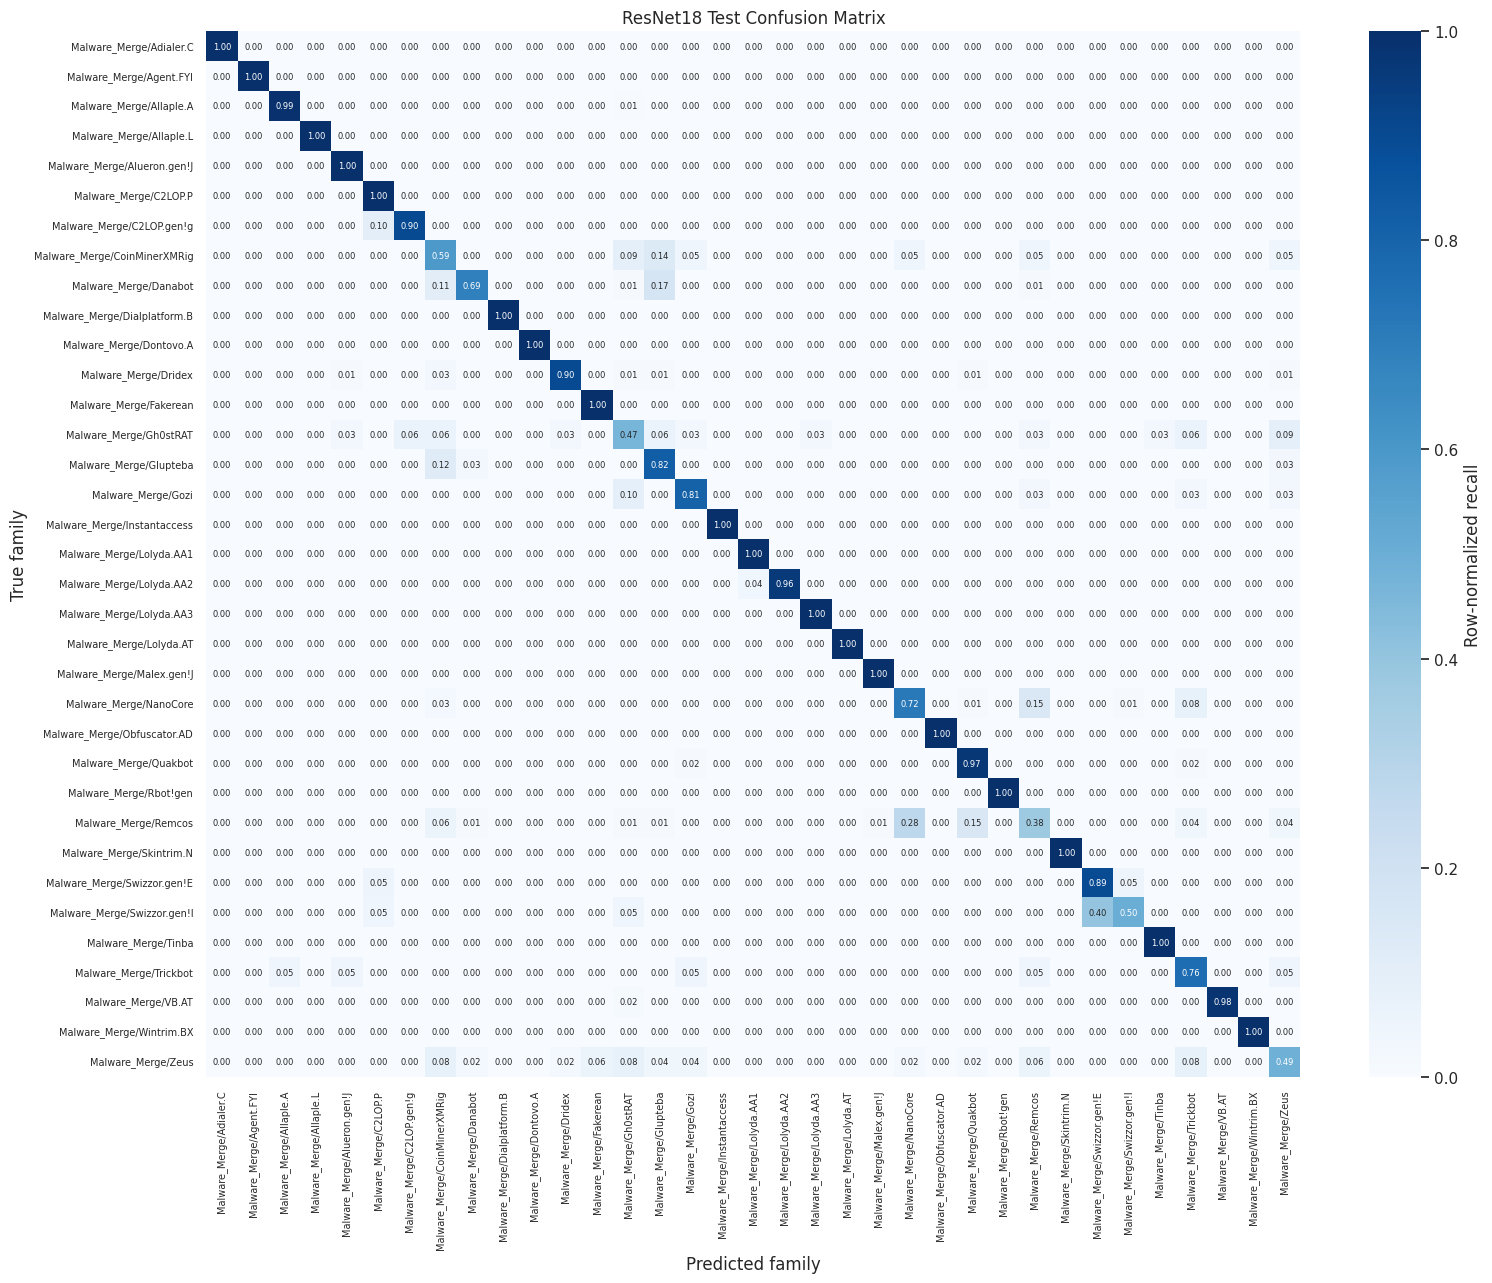


MobileNetV3Small classification report


,precision,recall,f1-score,support
Malware_Merge/Adialer.C,1.000,1.000,1.000,6.000
Malware_Merge/Agent.FYI,1.000,1.000,1.000,17.000
Malware_Merge/Allaple.A,0.989,0.593,0.742,150.000
Malware_Merge/Allaple.L,1.000,0.580,0.734,150.000
Malware_Merge/Alueron.gen!J,0.732,1.000,0.845,30.000
Malware_Merge/C2LOP.P,0.710,1.000,0.830,22.000
Malware_Merge/C2LOP.gen!g,1.000,0.600,0.750,30.000
Malware_Merge/CoinMinerXMRig,0.103,0.364,0.160,22.000
Malware_Merge/Danabot,0.786,0.440,0.564,75.000
Malware_Merge/Dialplatform.B,0.964,1.000,0.982,27.000


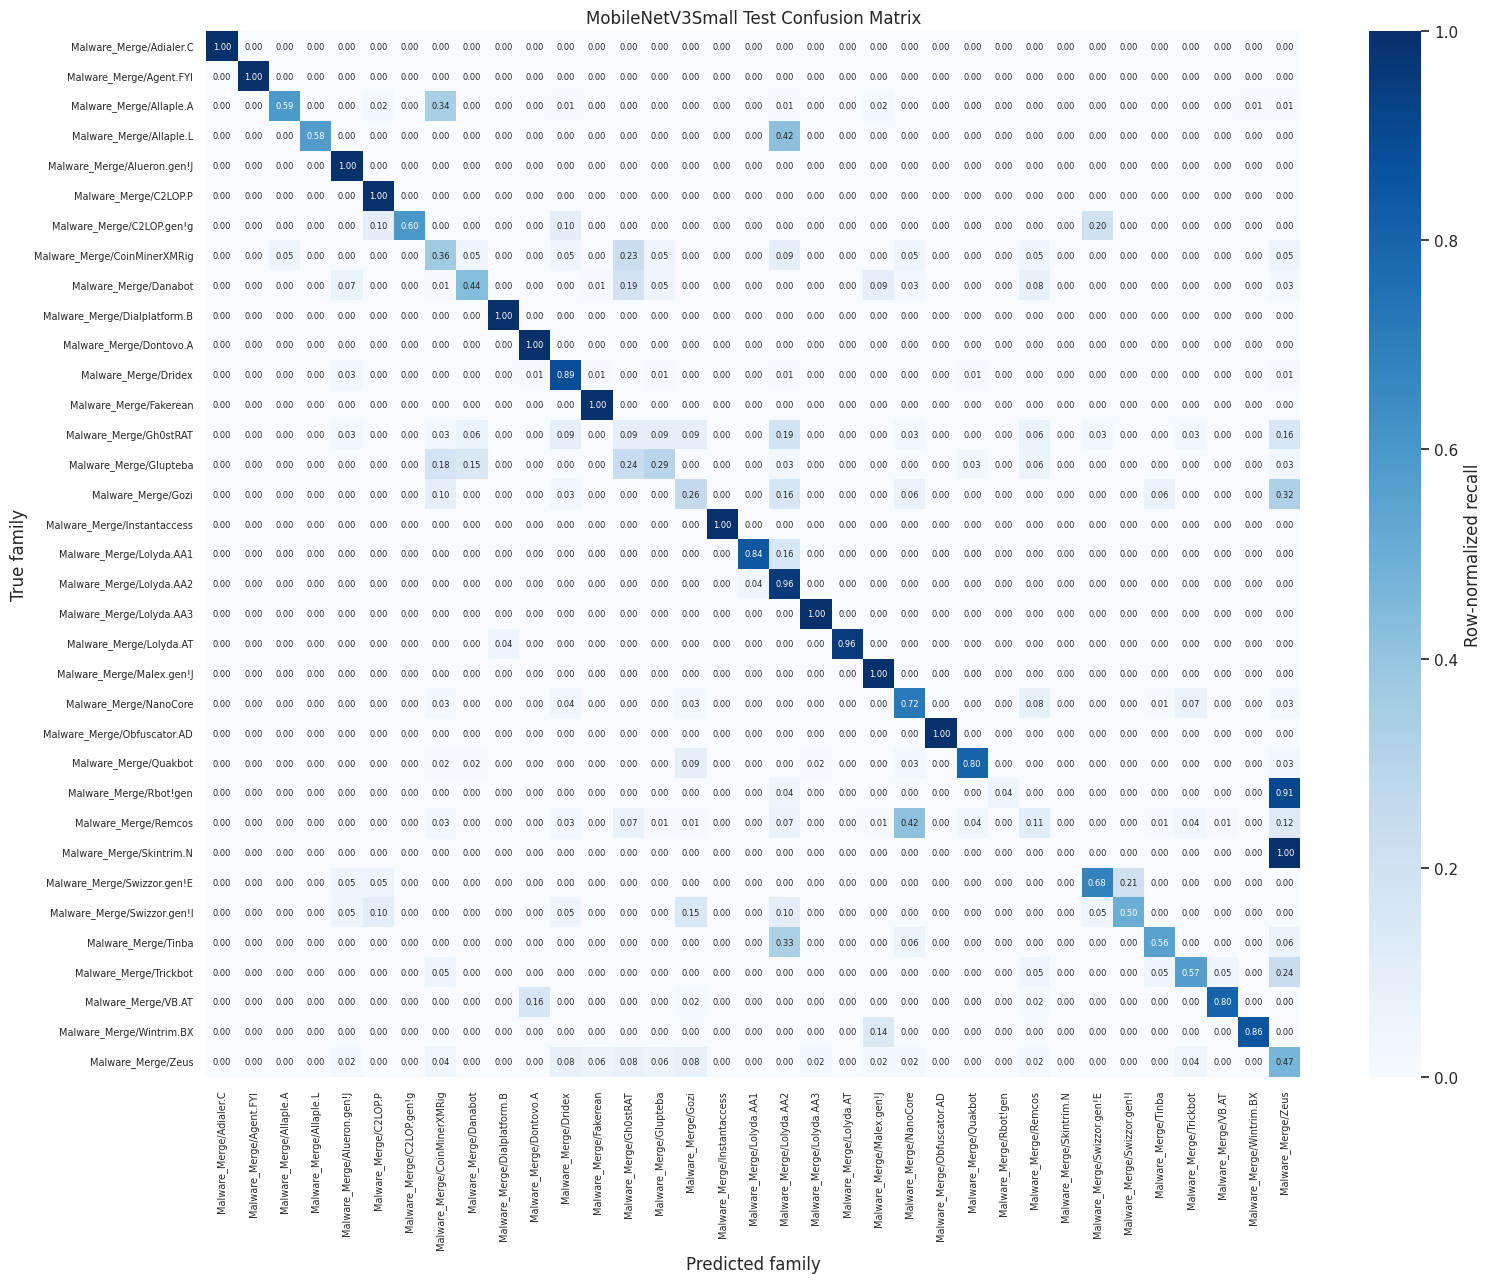


PatchGCN classification report


,precision,recall,f1-score,support
Malware_Merge/Adialer.C,0.083,1.000,0.154,6.000
Malware_Merge/Agent.FYI,0.654,1.000,0.791,17.000
Malware_Merge/Allaple.A,0.196,0.193,0.195,150.000
Malware_Merge/Allaple.L,0.962,1.000,0.980,150.000
Malware_Merge/Alueron.gen!J,0.368,0.933,0.528,30.000
Malware_Merge/C2LOP.P,0.059,0.045,0.051,22.000
Malware_Merge/C2LOP.gen!g,0.324,0.767,0.455,30.000
Malware_Merge/CoinMinerXMRig,0.000,0.000,0.000,22.000
Malware_Merge/Danabot,0.400,0.027,0.050,75.000
Malware_Merge/Dialplatform.B,0.871,1.000,0.931,27.000


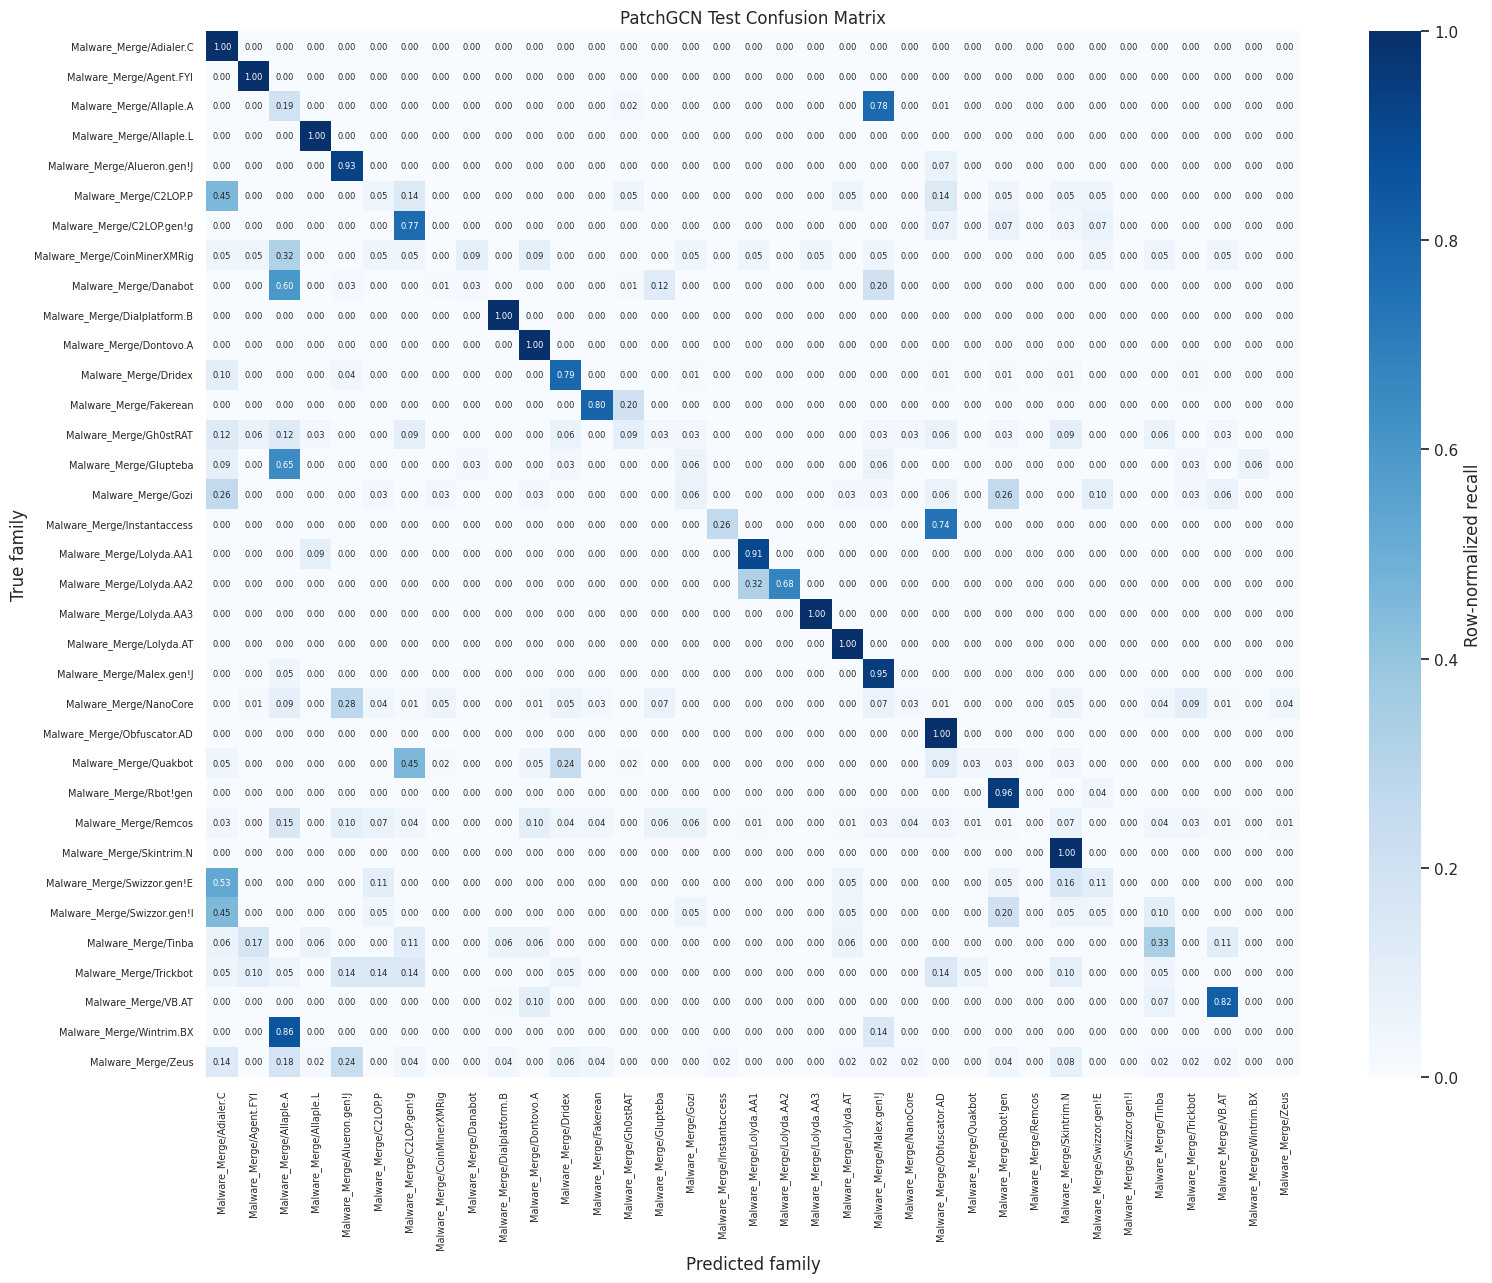

In [11]:
# Export classification reports and show normalized confusion matrices
for name, result in results.items():
    report = pd.DataFrame(
        classification_report(
            result["actual"],
            result["predicted"],
            target_names=encoder.classes_,
            output_dict=True,
            zero_division=0,
        )
    ).T
    report.to_csv(OUTPUT_DIR / f"{name.lower()}_classification_report.csv")
    print(f"\n{name} classification report")
    display(report.round(3))

    matrix = confusion_matrix(
        result["actual"], result["predicted"], normalize="true"
    )
    plt.figure(figsize=(16, 13))

    # Added annot=True, fmt=".2f", and annot_kws to show values in cells cleanly
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 6},
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=encoder.classes_,
        yticklabels=encoder.classes_,
        cbar_kws={"label": "Row-normalized recall"},
    )

    plt.title(f"{name} Test Confusion Matrix")
    plt.xlabel("Predicted family")
    plt.ylabel("True family")
    plt.xticks(rotation=90, fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.show()

In [12]:
# Print the final result locations
best = comparison.iloc[0]
print(f"Best model by test macro F1: {best.model} ({best.f1_macro:.4f})")
print("Saved outputs:", OUTPUT_DIR)

Best model by test macro F1: ResNet18 (0.8615)
Saved outputs: /kaggle/working/task2_outputs
